<a href="https://www.kaggle.com/code/sonawanelalitsunil/us-tariff-impact-on-trade-ml-100?scriptVersionId=232788456" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/us-tariffs-2025/Tariff Calculations.csv
/kaggle/input/us-tariffs-2025/Tariff Calculations plus Population.csv


##  TItle : US Tariff Impact on Trade

#### An analytical report examining the effects of US-imposed tariffs on international trade volumes, partner countries, and product categories.

## Import dataset

In [2]:
file_plus = '/kaggle/input/us-tariffs-2025/Tariff Calculations plus Population.csv'
file_standard = '/kaggle/input/us-tariffs-2025/Tariff Calculations.csv'

In [3]:
# Load datasets with the correct delimiter and encoding
df_plus = pd.read_csv(file_plus, delimiter=';', encoding='ascii')
df_standard = pd.read_csv(file_standard, delimiter=';', encoding='ascii')

In [4]:
df_plus.head()

,Country,US 2024 Deficit,US 2024 Exports,US 2024 Imports (Customs Basis),Trump Tariffs Alleged,Trump Response,Population
0,Afghanistan,-11.1,11.4,22.6,49%,25%,41454761.0
1,Albania,13.4,141.7,128.3,10%,10%,2745972.0
2,Algeria,"-1,447.10","1,014.50","2,461.60",59%,29%,46164219.0
3,Andorra,1.5,4.9,3.4,10%,10%,80856.0
4,Angola,"-1,186.90",682.4,"1,869.20",63%,32%,36749906.0


In [5]:
df_plus.tail()

,Country,US 2024 Deficit,US 2024 Exports,US 2024 Imports (Customs Basis),Trump Tariffs Alleged,Trump Response,Population
199,Vietnam,"-123,463.00","13,098.20","136,561.20",90%,45%,100352192.0
200,West Bank Administered by Israel,-2.3,3.7,6,38%,19%,NaN
201,Yemen,125.2,134.1,8.9,10%,10%,39390799.0
202,Zambia,-55.3,113.8,169.1,33%,16%,20723965.0
203,Zimbabwe,-24.1,43.8,67.8,36%,18%,16340822.0


In [6]:
df_plus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          204 non-null    object 
 1   US 2024 Deficit                  204 non-null    object 
 2   US 2024 Exports                  204 non-null    object 
 3   US 2024 Imports (Customs Basis)  204 non-null    object 
 4   Trump Tariffs Alleged            204 non-null    object 
 5   Trump Response                   204 non-null    object 
 6   Population                       172 non-null    float64
dtypes: float64(1), object(6)
memory usage: 11.3+ KB


In [7]:
df_plus.isnull().sum()

Country                             0
US 2024 Deficit                     0
US 2024 Exports                     0
US 2024 Imports (Customs Basis)     0
Trump Tariffs Alleged               0
Trump Response                      0
Population                         32
dtype: int64

In [8]:
df_plus.describe()

,Population
count,1.720000e+02
mean,4.286567e+07
std,1.602899e+08
min,9.816000e+03
25%,8.149932e+05
50%,6.833880e+06
75%,2.831881e+07
max,1.438070e+09


In [9]:
df_plus.duplicated().sum()

0

In [10]:
df_plus.shape

(204, 7)

In [11]:
df_plus.columns

Index(['Country', 'US 2024 Deficit', 'US 2024 Exports',
       'US 2024 Imports (Customs Basis)', 'Trump Tariffs Alleged',
       'Trump Response', 'Population'],
      dtype='object')

## Data visualization 

In [12]:
import re

def convert_to_numeric(x):
    # Removing any character that is not a digit, period, minus sign
    try:
        if isinstance(x, str):
            # Remove commas and any currency symbols
            x = re.sub(r'[^0-9.\-]', '', x)
        return float(x) if x not in [None, ''] else np.nan
    except Exception as e:
        # This error handling is crucial if similar datasets have unexpected formats
        return np.nan

In [13]:
# List of columns to convert
cols_to_convert = ['US 2024 Deficit', 'US 2024 Exports', 'US 2024 Imports (Customs Basis)']


In [14]:
for col in cols_to_convert:
    df_plus[col + '_num'] = df_plus[col].apply(convert_to_numeric)


In [15]:
# Check the conversion
print(df_plus[[col + '_num' for col in cols_to_convert]].head())

   US 2024 Deficit_num  US 2024 Exports_num  \
0                -11.1                 11.4   
1                 13.4                141.7   
2              -1447.1               1014.5   
3                  1.5                  4.9   
4              -1186.9                682.4   

   US 2024 Imports (Customs Basis)_num  
0                                 22.6  
1                                128.3  
2                               2461.6  
3                                  3.4  
4                               1869.2  


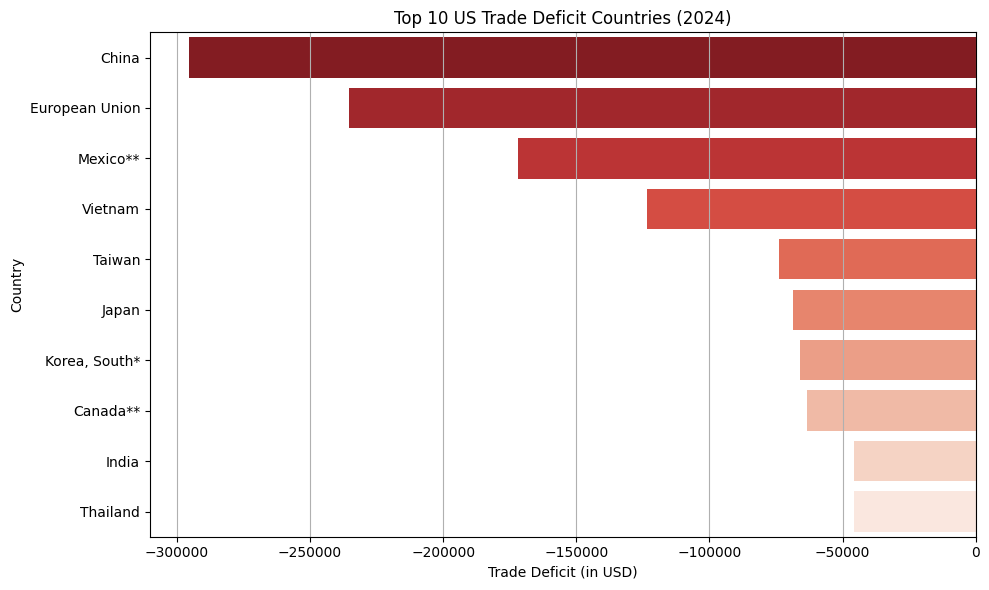

In [16]:
top_deficit = df_plus.sort_values('US 2024 Deficit_num').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_deficit, x='US 2024 Deficit_num', y='Country', palette='Reds_r')
plt.title("Top 10 US Trade Deficit Countries (2024)")
plt.xlabel("Trade Deficit (in USD)")
plt.ylabel("Country")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

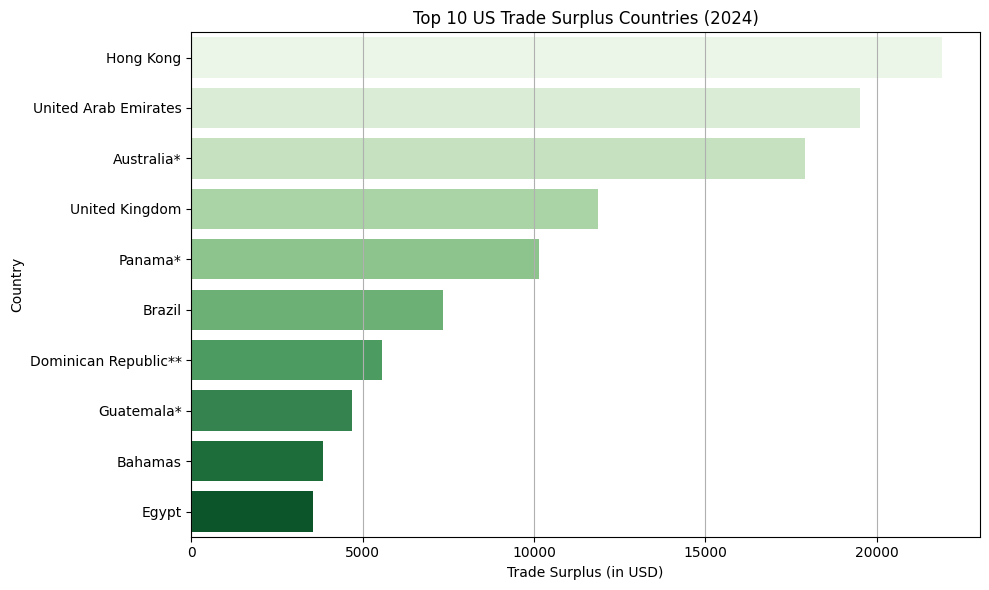

In [17]:
top_surplus = df_plus.sort_values('US 2024 Deficit_num', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_surplus, x='US 2024 Deficit_num', y='Country', palette='Greens')
plt.title("Top 10 US Trade Surplus Countries (2024)")
plt.xlabel("Trade Surplus (in USD)")
plt.ylabel("Country")
plt.grid(axis='x')
plt.tight_layout()
plt.show()


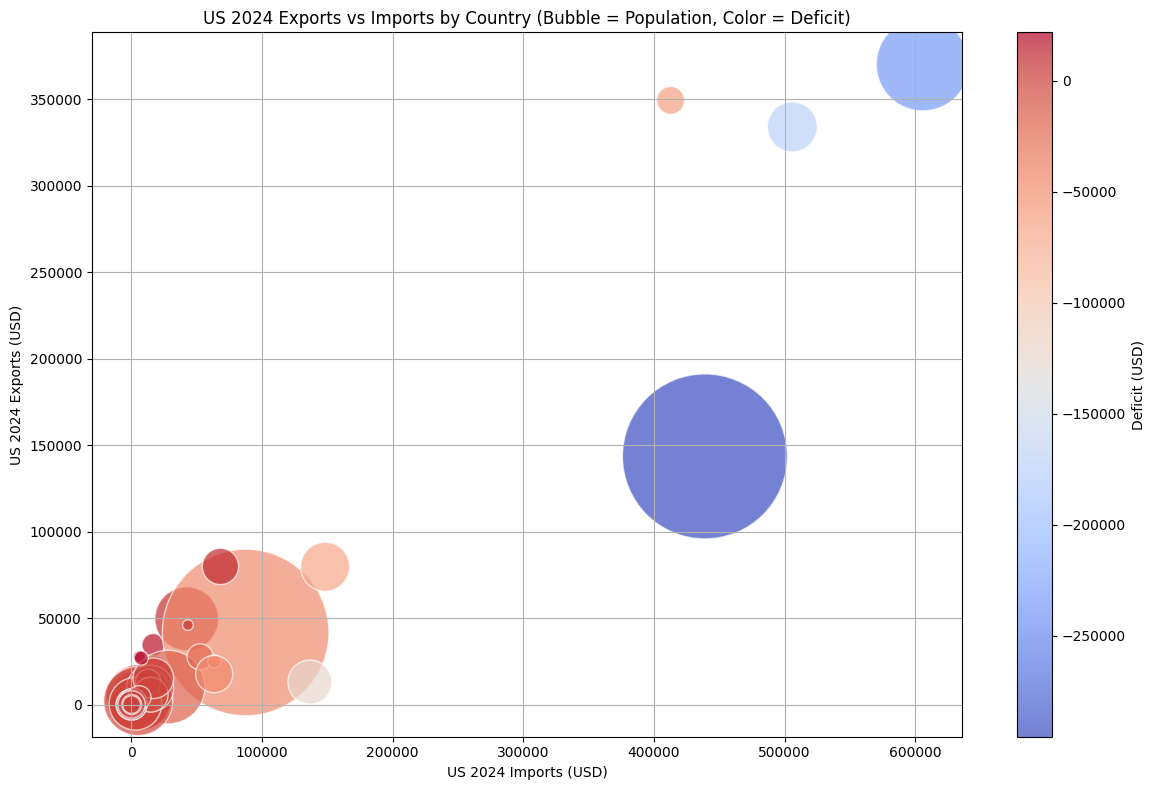

In [18]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_plus['US 2024 Imports (Customs Basis)_num'],
    df_plus['US 2024 Exports_num'],
    s=df_plus['Population'] / 1e5,  # Bubble size scaled
    c=df_plus['US 2024 Deficit_num'], cmap='coolwarm', alpha=0.7, edgecolors='w'
)
plt.xlabel("US 2024 Imports (USD)")
plt.ylabel("US 2024 Exports (USD)")
plt.title("US 2024 Exports vs Imports by Country (Bubble = Population, Color = Deficit)")
plt.colorbar(scatter, label='Deficit (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()


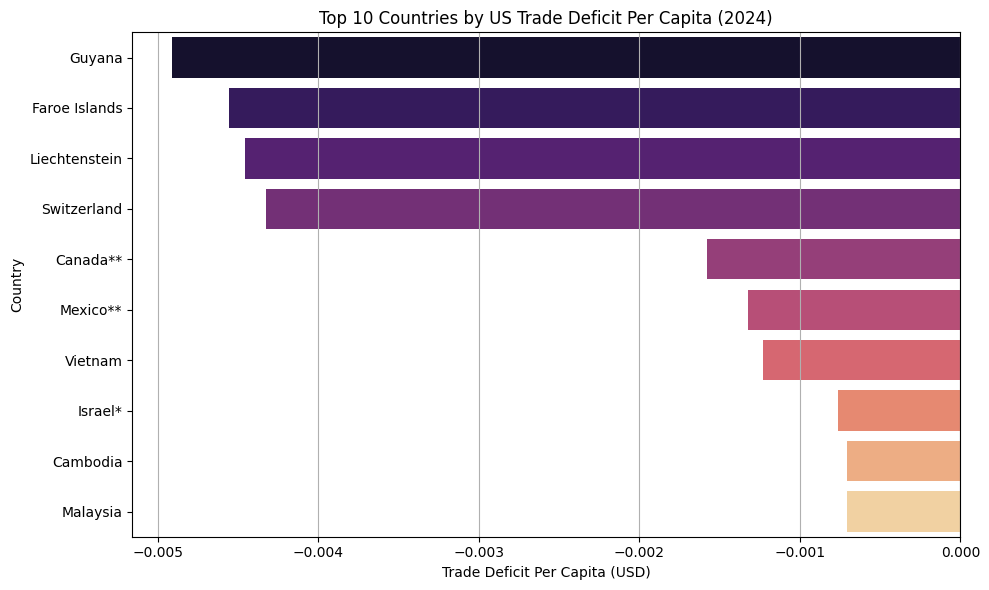

In [19]:
df_plus['Deficit per Capita'] = df_plus['US 2024 Deficit_num'] / df_plus['Population']

top_per_capita_deficit = df_plus.sort_values('Deficit per Capita').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_per_capita_deficit, x='Deficit per Capita', y='Country', palette='magma')
plt.title("Top 10 Countries by US Trade Deficit Per Capita (2024)")
plt.xlabel("Trade Deficit Per Capita (USD)")
plt.ylabel("Country")
plt.grid(axis='x')
plt.tight_layout()
plt.show()


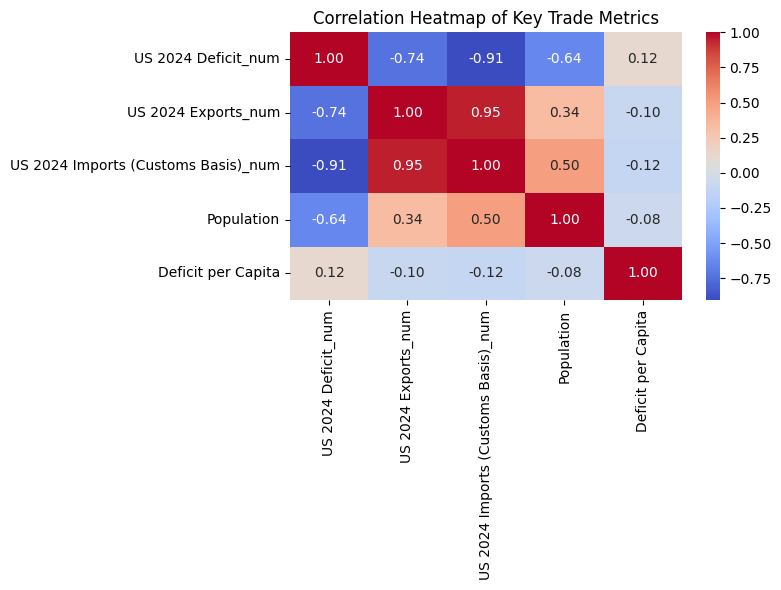

In [20]:
plt.figure(figsize=(8, 6))
numeric_cols = [col + '_num' for col in cols_to_convert] + ['Population', 'Deficit per Capita']
sns.heatmap(df_plus[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Key Trade Metrics")
plt.tight_layout()
plt.show()


## Predictive modeling

In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [22]:
# Create binary label: 1 = Deficit, 0 = Surplus
df_plus['Deficit_Flag'] = (df_plus['US 2024 Deficit_num'] < 0).astype(int)

In [23]:
print(df_plus.columns)

Index(['Country', 'US 2024 Deficit', 'US 2024 Exports',
       'US 2024 Imports (Customs Basis)', 'Trump Tariffs Alleged',
       'Trump Response', 'Population', 'US 2024 Deficit_num',
       'US 2024 Exports_num', 'US 2024 Imports (Customs Basis)_num',
       'Deficit per Capita', 'Deficit_Flag'],
      dtype='object')


In [24]:
le = LabelEncoder()
df_plus['Country'] = le.fit_transform(df_plus['Country'].astype(str))


In [25]:
# Define features and target
features = ['Country', 'US 2024 Deficit_num', 'US 2024 Exports_num',
            'US 2024 Imports (Customs Basis)_num', 'Population']
target = 'Deficit_Flag'


In [26]:
# Drop rows with any missing values in features or target
df_model = df_plus[features + [target]].dropna()
X = df_model[features]
y = df_model[target]


In [27]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Classifiers to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

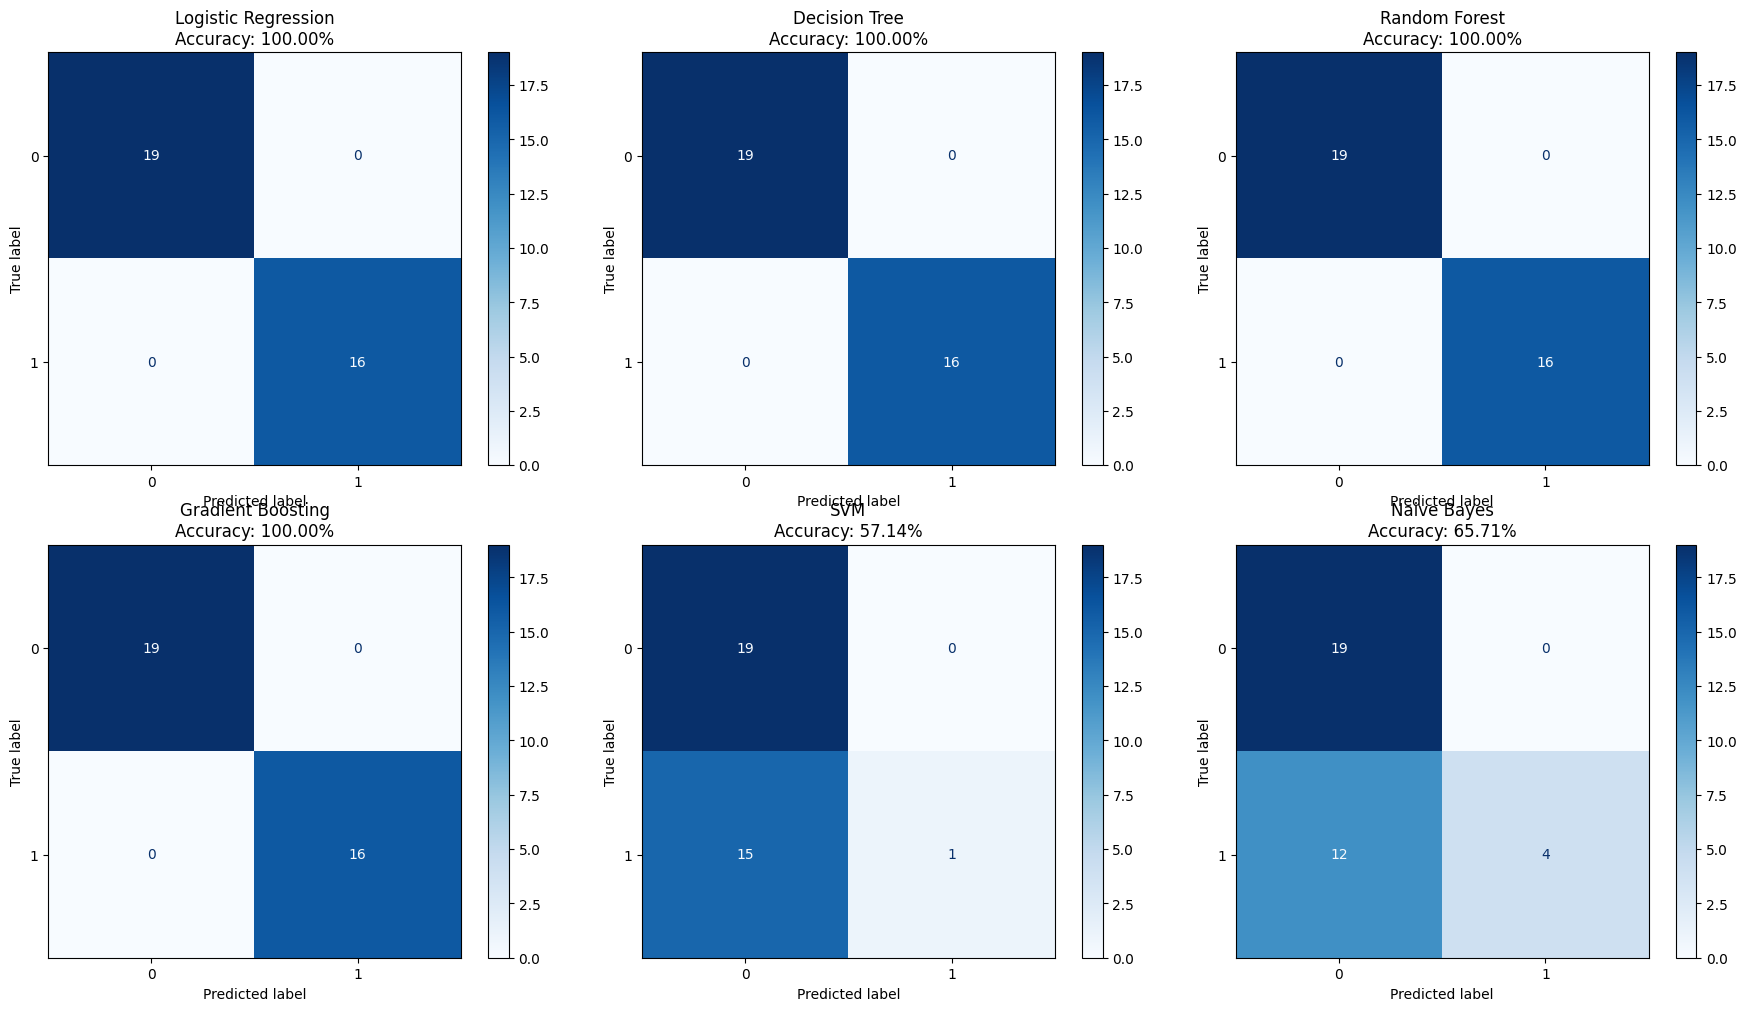

In [29]:
# Plot setup
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop through classifiers
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f"{name}\nAccuracy: {acc:.2f}%")

plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!